In [2]:
# 1. Import Library yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Membaca Dataset
df = pd.read_csv('ecommerce_customer_behavior_5000.csv')

# 3. Menampilkan 5 data teratas untuk memastikan data terbaca
print("Berhasil memuat dataset!")
display(df.head())

Berhasil memuat dataset!


,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,No,2022-01-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,Yes,2022-01-02
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,No,2022-01-03
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,No,2022-01-05


In [3]:
"""
Sistem Prediksi Pengembalian Barang E-commerce (Product Return Prediction)
-------------------------------------------------------------------------
Script ini memuat pipeline end-to-end machine learning untuk memprediksi
probabilitas pelanggan melakukan retur barang.

Kebutuhan Library:
pip install pandas numpy scikit-learn imbalanced-learn xgboost
"""

import pandas as pd
import numpy as np
import warnings

# Library untuk Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Library untuk Imbalanced Data dan Algoritma Model
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Mengabaikan peringatan (warnings) agar output terminal tetap bersih
warnings.filterwarnings('ignore')

def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Fungsi untuk memuat dataset dan melakukan pembersihan awal (Selection).
    """
    try:
        print("[1/5] Memuat dataset...")
        df = pd.read_csv(filepath)

        # 1. Selection: Membuang variabel yang tidak relevan (noise)
        kolom_dibuang = ['order_id', 'order_date']
        df = df.drop(columns=kolom_dibuang)

        # 2. Preprocessing: Menangani missing values (jika ada)
        # Menghapus baris yang memiliki nilai kosong agar data tetap valid
        df = df.dropna()

        print(f"      Berhasil memuat {df.shape[0]} baris dan {df.shape[1]} kolom.")
        return df

    except FileNotFoundError:
        print(f"Error: File '{filepath}' tidak ditemukan. Pastikan path file benar.")
        exit()

def transform_features(df: pd.DataFrame):
    """
    Fungsi untuk melakukan Feature Engineering dan Data Transformation.
    """
    print("[2/5] Melakukan Transformasi Fitur (Encoding)...")

    # 1. Target Encoding: Mengubah 'returned' (Yes/No) menjadi Biner (1/0)
    df['returned'] = df['returned'].map({'Yes': 1, 'No': 0})

    # Memisahkan Fitur (X) dan Target (y)
    X = df.drop(columns=['returned'])
    y = df['returned']

    # 2. One-Hot Encoding: Mengubah variabel kategorikal menjadi numerik
    kolom_kategorikal = ['customer_gender', 'product_category', 'payment_method']
    X = pd.get_dummies(X, columns=kolom_kategorikal, drop_first=True)

    # 3. Scaling Numerik (Opsional untuk XGBoost, tapi praktik yang baik)
    kolom_numerik = ['customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating']
    scaler = StandardScaler()
    X[kolom_numerik] = scaler.fit_transform(X[kolom_numerik])

    print("      Transformasi selesai. Menuju tahap pemisahan data.")
    return X, y

def balance_and_split_data(X: pd.DataFrame, y: pd.Series):
    """
    Fungsi untuk membagi data dan menangani ketidakseimbangan kelas (Imbalanced Data).
    """
    print("[3/5] Membagi Data dan Menerapkan SMOTE...")

    # Split Data: 80% Training, 20% Testing
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"      Distribusi Target sebelum SMOTE:\n{y_train.value_counts()}")

    # Menangani Imbalanced Data dengan SMOTE (Hanya pada Data Training!)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"      Distribusi Target setelah SMOTE:\n{y_train_smote.value_counts()}")

    return X_train_smote, X_test, y_train_smote, y_test

def train_and_evaluate_model(X_train, X_test, y_train, y_test):
    """
    Fungsi untuk melatih model XGBoost dan mengevaluasi kinerjanya.
    """
    print("\n[4/5] Melatih Model XGBoost Classifier...")

    # Inisialisasi Model XGBoost
    # Konfigurasi ini cocok untuk klasifikasi biner
    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )

    # Melatih (Training) Model
    model.fit(X_train, y_train)

    print("[5/5] Melakukan Prediksi dan Evaluasi...")
    # Prediksi pada Data Testing
    y_pred = model.predict(X_test)

    # Evaluasi Metrik
    print("\n" + "="*50)
    print("                HASIL EVALUASI MODEL                ")
    print("="*50)
    print(f"Akurasi Keseluruhan : {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("-" * 50)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Tidak Retur (0)', 'Retur (1)']))
    print("="*50)

    return model

if __name__ == "__main__":
    # Path dataset (sesuaikan dengan lokasi file CSV Anda)
    DATASET_PATH = 'ecommerce_customer_behavior_5000.csv'

    # --- MENJALANKAN PIPELINE ---
    print("Memulai Pipeline Prediksi Retur E-commerce\n" + "-"*40)

    # 1. Load Data
    data = load_and_clean_data(DATASET_PATH)

    # 2. Transformasi & Feature Engineering
    X_features, y_target = transform_features(data)

    # 3. Balancing (SMOTE) & Splitting
    X_train_resampled, X_test_final, y_train_resampled, y_test_final = balance_and_split_data(X_features, y_target)

    # 4 & 5. Training & Evaluasi
    trained_model = train_and_evaluate_model(X_train_resampled, X_test_final, y_train_resampled, y_test_final)

    print("\nPipeline Selesai! Model siap diintegrasikan atau dianalisis lebih lanjut (Feature Importance).")

Memulai Pipeline Prediksi Retur E-commerce
----------------------------------------
[1/5] Memuat dataset...
      Berhasil memuat 5000 baris dan 8 kolom.
[2/5] Melakukan Transformasi Fitur (Encoding)...
      Transformasi selesai. Menuju tahap pemisahan data.
[3/5] Membagi Data dan Menerapkan SMOTE...
      Distribusi Target sebelum SMOTE:
returned
1    2020
0    1980
Name: count, dtype: int64
      Distribusi Target setelah SMOTE:
returned
0    2020
1    2020
Name: count, dtype: int64

[4/5] Melatih Model XGBoost Classifier...
[5/5] Melakukan Prediksi dan Evaluasi...

                HASIL EVALUASI MODEL                
Akurasi Keseluruhan : 50.40%
--------------------------------------------------
Confusion Matrix:
[[254 241]
 [255 250]]
--------------------------------------------------
Classification Report:
                 precision    recall  f1-score   support

Tidak Retur (0)       0.50      0.51      0.51       495
      Retur (1)       0.51      0.50      0.50       505

   

Memulai Pipeline Prediksi Retur E-commerce
----------------------------------------
[1/5] Memuat dataset...
      Berhasil memuat 5000 baris dan 8 kolom.
[2/5] Melakukan Transformasi Fitur (Encoding)...
      Transformasi selesai. Menuju tahap pemisahan data.
[3/5] Membagi Data dan Menerapkan SMOTE...
      Distribusi Target sebelum SMOTE:
returned
1    2020
0    1980
Name: count, dtype: int64
      Distribusi Target setelah SMOTE:
returned
0    2020
1    2020
Name: count, dtype: int64

[4/5] Melatih Model XGBoost Classifier...
[5/5] Melakukan Prediksi dan Evaluasi...

                HASIL EVALUASI MODEL                
Akurasi Keseluruhan : 50.40%
--------------------------------------------------
Confusion Matrix:
[[254 241]
 [255 250]]
--------------------------------------------------
Classification Report:
                 precision    recall  f1-score   support

Tidak Retur (0)       0.50      0.51      0.51       495
      Retur (1)       0.51      0.50      0.50       505

   

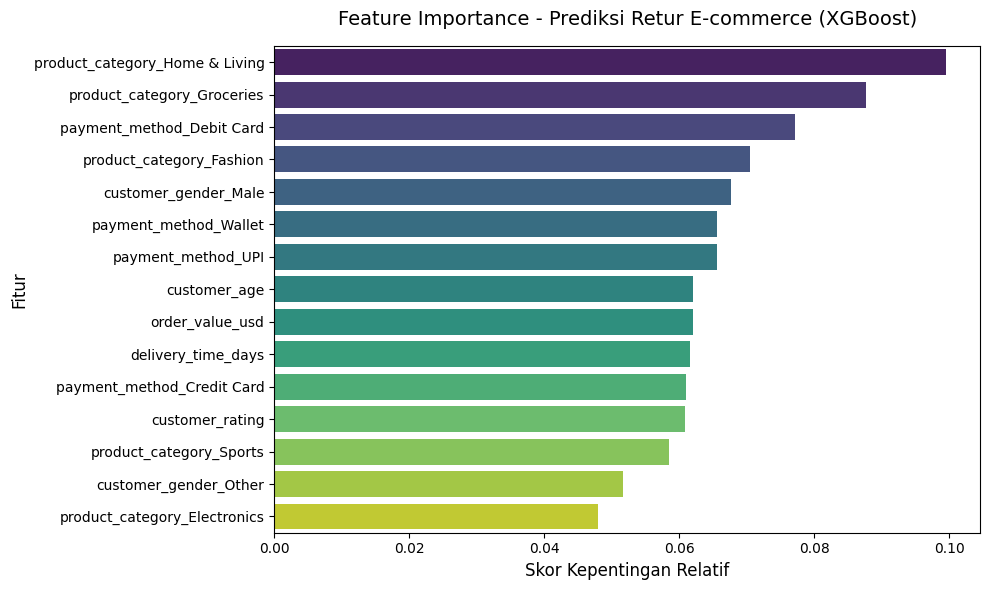

In [4]:
"""
Sistem Prediksi Pengembalian Barang E-commerce (Product Return Prediction)
-------------------------------------------------------------------------
Script ini memuat pipeline end-to-end machine learning untuk memprediksi
probabilitas pelanggan melakukan retur barang.

Kebutuhan Library:
pip install pandas numpy scikit-learn imbalanced-learn xgboost
"""

import pandas as pd
import numpy as np
import warnings

# Library untuk Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Library untuk Imbalanced Data dan Algoritma Model
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Mengabaikan peringatan (warnings) agar output terminal tetap bersih
warnings.filterwarnings('ignore')

def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Fungsi untuk memuat dataset dan melakukan pembersihan awal (Selection).
    """
    try:
        print("[1/5] Memuat dataset...")
        df = pd.read_csv(filepath)

        # 1. Selection: Membuang variabel yang tidak relevan (noise)
        kolom_dibuang = ['order_id', 'order_date']
        df = df.drop(columns=kolom_dibuang)

        # 2. Preprocessing: Menangani missing values (jika ada)
        # Menghapus baris yang memiliki nilai kosong agar data tetap valid
        df = df.dropna()

        print(f"      Berhasil memuat {df.shape[0]} baris dan {df.shape[1]} kolom.")
        return df

    except FileNotFoundError:
        print(f"Error: File '{filepath}' tidak ditemukan. Pastikan path file benar.")
        exit()

def transform_features(df: pd.DataFrame):
    """
    Fungsi untuk melakukan Feature Engineering dan Data Transformation.
    """
    print("[2/5] Melakukan Transformasi Fitur (Encoding)...")

    # 1. Target Encoding: Mengubah 'returned' (Yes/No) menjadi Biner (1/0)
    df['returned'] = df['returned'].map({'Yes': 1, 'No': 0})

    # Memisahkan Fitur (X) dan Target (y)
    X = df.drop(columns=['returned'])
    y = df['returned']

    # 2. One-Hot Encoding: Mengubah variabel kategorikal menjadi numerik
    kolom_kategorikal = ['customer_gender', 'product_category', 'payment_method']
    X = pd.get_dummies(X, columns=kolom_kategorikal, drop_first=True)

    # 3. Scaling Numerik (Opsional untuk XGBoost, tapi praktik yang baik)
    kolom_numerik = ['customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating']
    scaler = StandardScaler()
    X[kolom_numerik] = scaler.fit_transform(X[kolom_numerik])

    print("      Transformasi selesai. Menuju tahap pemisahan data.")
    return X, y

def balance_and_split_data(X: pd.DataFrame, y: pd.Series):
    """
    Fungsi untuk membagi data dan menangani ketidakseimbangan kelas (Imbalanced Data).
    """
    print("[3/5] Membagi Data dan Menerapkan SMOTE...")

    # Split Data: 80% Training, 20% Testing
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"      Distribusi Target sebelum SMOTE:\n{y_train.value_counts()}")

    # Menangani Imbalanced Data dengan SMOTE (Hanya pada Data Training!)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"      Distribusi Target setelah SMOTE:\n{y_train_smote.value_counts()}")

    return X_train_smote, X_test, y_train_smote, y_test

def train_and_evaluate_model(X_train, X_test, y_train, y_test):
    """
    Fungsi untuk melatih model XGBoost dan mengevaluasi kinerjanya.
    """
    print("\n[4/5] Melatih Model XGBoost Classifier...")

    # Inisialisasi Model XGBoost
    # Konfigurasi ini cocok untuk klasifikasi biner
    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )

    # Melatih (Training) Model
    model.fit(X_train, y_train)

    print("[5/5] Melakukan Prediksi dan Evaluasi...")
    # Prediksi pada Data Testing
    y_pred = model.predict(X_test)

    # Evaluasi Metrik
    print("\n" + "="*50)
    print("                HASIL EVALUASI MODEL                ")
    print("="*50)
    print(f"Akurasi Keseluruhan : {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("-" * 50)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Tidak Retur (0)', 'Retur (1)']))
    print("="*50)

    return model

def plot_feature_importance(model, feature_names):
    """
    Fungsi untuk memvisualisasikan tingkat kepentingan fitur (Feature Importance) dari model XGBoost.
    """
    print("\n[6/6] Menganalisis Feature Importance...")

    # 1. Mengambil nilai importance dari model XGBoost
    importance = model.feature_importances_

    # 2. Membuat DataFrame untuk memudahkan analisis dan plotting
    fi_df = pd.DataFrame({
        'Fitur': feature_names,
        'Kepentingan': importance
    }).sort_values(by='Kepentingan', ascending=False)

    # 3. Menampilkan ke Terminal
    print("\nTabel Feature Importance (Semakin tinggi = Semakin berpengaruh):")
    print(fi_df.to_string(index=False))

    # 4. Membuat Visualisasi Grafik
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Kepentingan', y='Fitur', data=fi_df, palette='viridis')

    plt.title('Feature Importance - Prediksi Retur E-commerce (XGBoost)', fontsize=14, pad=15)
    plt.xlabel('Skor Kepentingan Relatif', fontsize=12)
    plt.ylabel('Fitur', fontsize=12)
    plt.tight_layout()

    # 5. Menyimpan file hasil grafik
    file_output = 'feature_importance_plot.png'
    plt.savefig(file_output, dpi=300)
    print(f"\n      [INFO] Visualisasi Feature Importance berhasil disimpan sebagai '{file_output}'.")
    # plt.show() # Hilangkan tanda pagar (#) jika ingin grafiknya otomatis popup/tampil saat di-run

if __name__ == "__main__":
    # Path dataset (sesuaikan dengan lokasi file CSV Anda)
    DATASET_PATH = 'ecommerce_customer_behavior_5000.csv'

    # --- MENJALANKAN PIPELINE ---
    print("Memulai Pipeline Prediksi Retur E-commerce\n" + "-"*40)

    # 1. Load Data
    data = load_and_clean_data(DATASET_PATH)

    # 2. Transformasi & Feature Engineering
    X_features, y_target = transform_features(data)

    # 3. Balancing (SMOTE) & Splitting
    X_train_resampled, X_test_final, y_train_resampled, y_test_final = balance_and_split_data(X_features, y_target)

    # 4 & 5. Training & Evaluasi
    trained_model = train_and_evaluate_model(X_train_resampled, X_test_final, y_train_resampled, y_test_final)

    # 6. Analisis Feature Importance
    plot_feature_importance(trained_model, X_features.columns)

    print("\nPipeline Selesai! Evaluasi model dan feature importance telah dieksekusi.")

Memulai Pipeline Prediksi Retur E-commerce (Versi Iterasi KDD)
------------------------------------------------------------
[1/6] Memuat dataset...
      Berhasil memuat 5000 baris dan 8 kolom.
[2/6] Melakukan Feature Engineering...
      Berhasil membuat 3 fitur baru. Total kolom saat ini: 11
[3/6] Melakukan Transformasi Fitur (Encoding & Scaling)...
[4/6] Membagi Data dan Menerapkan SMOTE...

[5/6] Melatih Model dan Cross-Validation...
      Akurasi Cross-Validation (5 Folds): [0.51608911 0.49628713 0.48019802 0.51485149 0.47524752]
      Rata-rata Akurasi CV: 49.65% (+/- 3.39%)

                HASIL EVALUASI MODEL                
Akurasi Test Set : 49.10%
--------------------------------------------------
Confusion Matrix:
[[250 245]
 [264 241]]
--------------------------------------------------
Classification Report:
                 precision    recall  f1-score   support

Tidak Retur (0)       0.49      0.51      0.50       495
      Retur (1)       0.50      0.48      0.49     

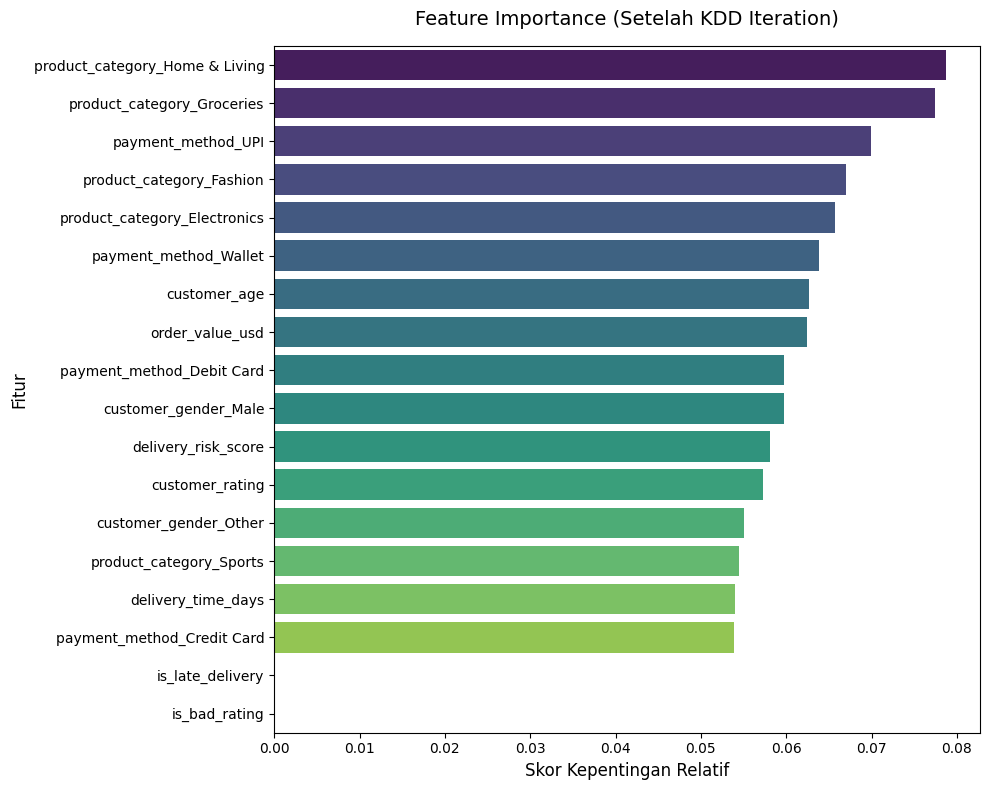

In [5]:
"""
Sistem Prediksi Pengembalian Barang E-commerce (Product Return Prediction)
-------------------------------------------------------------------------
Script ini memuat pipeline end-to-end machine learning untuk memprediksi
probabilitas pelanggan melakukan retur barang.

Kebutuhan Library:
pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn
"""

import pandas as pd
import numpy as np
import warnings

# Library untuk Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Library untuk Imbalanced Data dan Algoritma Model
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Mengabaikan peringatan (warnings) agar output terminal tetap bersih
warnings.filterwarnings('ignore')

def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Fungsi untuk memuat dataset dan melakukan pembersihan awal (Selection).
    """
    try:
        print("[1/6] Memuat dataset...")
        df = pd.read_csv(filepath)

        # 1. Selection: Membuang variabel yang tidak relevan (noise)
        kolom_dibuang = ['order_id', 'order_date']
        df = df.drop(columns=kolom_dibuang)

        # 2. Preprocessing: Menangani missing values
        df = df.dropna()

        print(f"      Berhasil memuat {df.shape[0]} baris dan {df.shape[1]} kolom.")
        return df

    except FileNotFoundError:
        print(f"Error: File '{filepath}' tidak ditemukan. Pastikan path file benar.")
        exit()

def perform_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    KDD Iteration: Melakukan Feature Engineering untuk menciptakan sinyal prediktif
    berdasarkan domain knowledge bisnis e-commerce.
    """
    print("[2/6] Melakukan Feature Engineering...")

    # Fitur Baru 1: Indikator Keterlambatan Pengiriman (Misal threshold = 7 hari)
    df['is_late_delivery'] = (df['delivery_time_days'] > 7).astype(int)

    # Fitur Baru 2: Indikator Rating Buruk
    df['is_bad_rating'] = (df['customer_rating'] <= 2.5).astype(int)

    # Fitur Baru 3: Risk Score (Kombinasi rating buruk dan keterlambatan)
    df['delivery_risk_score'] = df['is_late_delivery'] + df['is_bad_rating']

    print(f"      Berhasil membuat 3 fitur baru. Total kolom saat ini: {df.shape[1]}")
    return df

def transform_features(df: pd.DataFrame):
    """
    Fungsi untuk melakukan Encoding dan Data Transformation.
    """
    print("[3/6] Melakukan Transformasi Fitur (Encoding & Scaling)...")

    # Target Encoding
    df['returned'] = df['returned'].map({'Yes': 1, 'No': 0})

    X = df.drop(columns=['returned'])
    y = df['returned']

    # One-Hot Encoding untuk fitur kategorikal bawaan
    kolom_kategorikal = ['customer_gender', 'product_category', 'payment_method']
    X = pd.get_dummies(X, columns=kolom_kategorikal, drop_first=True)

    # Scaling Numerik
    kolom_numerik = ['customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating']
    scaler = StandardScaler()
    X[kolom_numerik] = scaler.fit_transform(X[kolom_numerik])

    return X, y

def balance_and_split_data(X: pd.DataFrame, y: pd.Series):
    """
    Fungsi membagi data dan menangani ketidakseimbangan kelas (Imbalanced Data).
    """
    print("[4/6] Membagi Data dan Menerapkan SMOTE...")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    return X_train_smote, X_test, y_train_smote, y_test

def train_and_evaluate_model(X_train, X_test, y_train, y_test):
    """
    Melatih model, melakukan Cross-Validation, dan mengevaluasi kinerjanya.
    """
    print("\n[5/6] Melatih Model dan Cross-Validation...")

    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss'
    )

    # Melakukan 5-Fold Cross Validation pada Data Training untuk validasi ekstra
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"      Akurasi Cross-Validation (5 Folds): {cv_scores}")
    print(f"      Rata-rata Akurasi CV: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 2 * 100:.2f}%)")

    # Melatih model final
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    print("\n" + "="*50)
    print("                HASIL EVALUASI MODEL                ")
    print("="*50)
    print(f"Akurasi Test Set : {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("-" * 50)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Tidak Retur (0)', 'Retur (1)']))
    print("="*50)

    return model

def plot_feature_importance(model, feature_names):
    """
    Memvisualisasikan tingkat kepentingan fitur dari model XGBoost.
    """
    print("\n[6/6] Menganalisis Feature Importance...")

    importance = model.feature_importances_

    fi_df = pd.DataFrame({
        'Fitur': feature_names,
        'Kepentingan': importance
    }).sort_values(by='Kepentingan', ascending=False)

    print("\nTabel Feature Importance (Top 10):")
    print(fi_df.head(10).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Kepentingan', y='Fitur', data=fi_df, palette='viridis')

    plt.title('Feature Importance (Setelah KDD Iteration)', fontsize=14, pad=15)
    plt.xlabel('Skor Kepentingan Relatif', fontsize=12)
    plt.ylabel('Fitur', fontsize=12)
    plt.tight_layout()

    file_output = 'feature_importance_plot_v2.png'
    plt.savefig(file_output, dpi=300)
    print(f"\n      [INFO] Visualisasi Feature Importance disimpan sebagai '{file_output}'.")

if __name__ == "__main__":
    DATASET_PATH = 'ecommerce_customer_behavior_5000.csv'

    print("Memulai Pipeline Prediksi Retur E-commerce (Versi Iterasi KDD)\n" + "-"*60)

    data = load_and_clean_data(DATASET_PATH)
    data_engineered = perform_feature_engineering(data)
    X_features, y_target = transform_features(data_engineered)

    X_train_res, X_test_fin, y_train_res, y_test_fin = balance_and_split_data(X_features, y_target)

    trained_model = train_and_evaluate_model(X_train_res, X_test_fin, y_train_res, y_test_fin)

    plot_feature_importance(trained_model, X_features.columns)

    print("\nPipeline Iterasi KDD Selesai!")

Memulai Pipeline Prediksi Retur E-commerce (Tahap Akhir & Deployment)
----------------------------------------------------------------------
[1/7] Memuat dataset...
      Berhasil memuat 5000 baris dan 8 kolom.
[2/7] Melakukan Feature Engineering...
      Berhasil membuat 3 fitur baru. Total kolom saat ini: 11
[3/7] Melakukan Transformasi Fitur (Encoding & Scaling)...
[4/7] Membagi Data dan Menerapkan SMOTE...

[5/7] Melakukan Hyperparameter Tuning (GridSearchCV)...
      (Proses ini mungkin memakan waktu beberapa saat)
      Parameter Terbaik: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}

[6/7] Evaluasi Model Final...

                HASIL EVALUASI MODEL                
Akurasi Test Set : 48.30%
--------------------------------------------------
Classification Report:
                 precision    recall  f1-score   support

Tidak Retur (0)       0.48      0.51      0.49       495
      Retur (1)       0.49      0.46      0.47       505

       accuracy                 

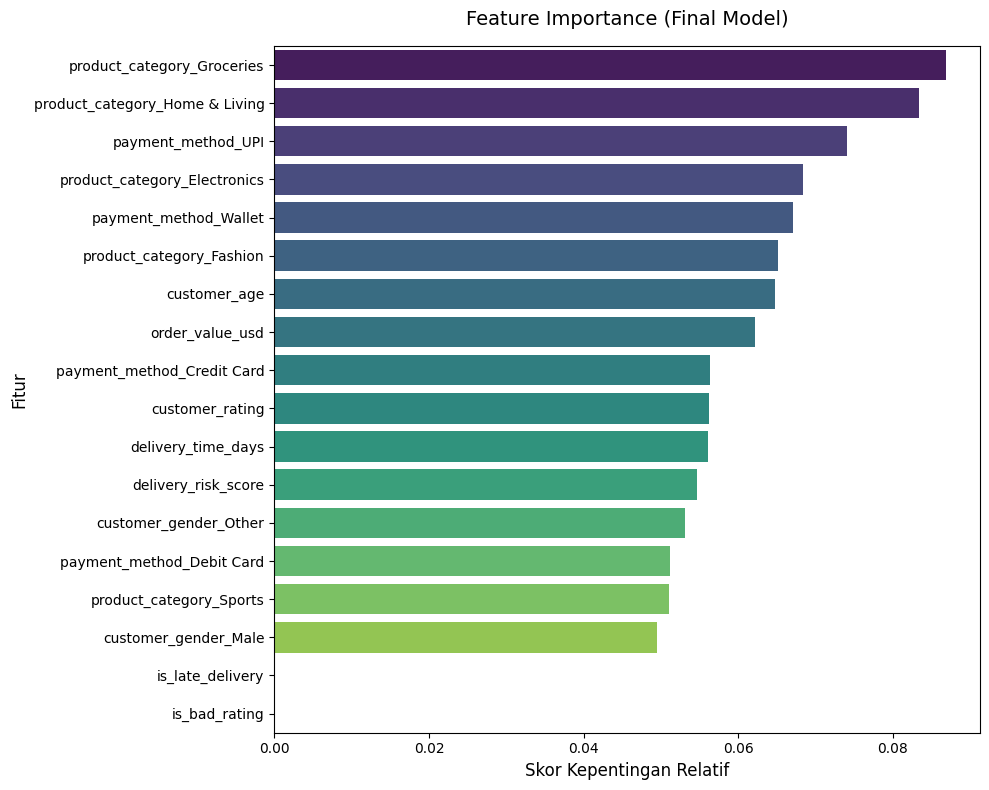

In [6]:
"""
Sistem Prediksi Pengembalian Barang E-commerce (Product Return Prediction)
-------------------------------------------------------------------------
Script ini memuat pipeline end-to-end machine learning untuk memprediksi
probabilitas pelanggan melakukan retur barang.

Kebutuhan Library:
pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn joblib
"""

import pandas as pd
import numpy as np
import warnings
import joblib # Untuk menyimpan model (Deployment)

# Library untuk Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Library untuk Imbalanced Data dan Algoritma Model
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Mengabaikan peringatan (warnings) agar output terminal tetap bersih
warnings.filterwarnings('ignore')

def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Fungsi untuk memuat dataset dan melakukan pembersihan awal (Selection).
    """
    try:
        print("[1/7] Memuat dataset...")
        df = pd.read_csv(filepath)
        kolom_dibuang = ['order_id', 'order_date']
        df = df.drop(columns=kolom_dibuang)
        df = df.dropna()
        print(f"      Berhasil memuat {df.shape[0]} baris dan {df.shape[1]} kolom.")
        return df
    except FileNotFoundError:
        print(f"Error: File '{filepath}' tidak ditemukan. Pastikan path file benar.")
        exit()

def perform_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    KDD Iteration: Melakukan Feature Engineering.
    """
    print("[2/7] Melakukan Feature Engineering...")
    df['is_late_delivery'] = (df['delivery_time_days'] > 7).astype(int)
    df['is_bad_rating'] = (df['customer_rating'] <= 2.5).astype(int)
    df['delivery_risk_score'] = df['is_late_delivery'] + df['is_bad_rating']
    print(f"      Berhasil membuat 3 fitur baru. Total kolom saat ini: {df.shape[1]}")
    return df

def transform_features(df: pd.DataFrame):
    """
    Fungsi untuk melakukan Encoding dan Data Transformation.
    """
    print("[3/7] Melakukan Transformasi Fitur (Encoding & Scaling)...")
    df['returned'] = df['returned'].map({'Yes': 1, 'No': 0})
    X = df.drop(columns=['returned'])
    y = df['returned']

    kolom_kategorikal = ['customer_gender', 'product_category', 'payment_method']
    X = pd.get_dummies(X, columns=kolom_kategorikal, drop_first=True)

    kolom_numerik = ['customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating']
    scaler = StandardScaler()
    X[kolom_numerik] = scaler.fit_transform(X[kolom_numerik])

    # Menyimpan scaler untuk kebutuhan prediksi di masa depan (Deployment)
    joblib.dump(scaler, 'scaler_ecommerce.joblib')

    return X, y

def balance_and_split_data(X: pd.DataFrame, y: pd.Series):
    """
    Fungsi membagi data dan menangani Imbalanced Data dengan SMOTE.
    """
    print("[4/7] Membagi Data dan Menerapkan SMOTE...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    return X_train_smote, X_test, y_train_smote, y_test

def tune_and_train_model(X_train, y_train):
    """
    Melakukan Hyperparameter Tuning dengan GridSearchCV untuk performa maksimal.
    """
    print("\n[5/7] Melakukan Hyperparameter Tuning (GridSearchCV)...")
    print("      (Proses ini mungkin memakan waktu beberapa saat)")

    # Menentukan parameter yang akan diuji
    param_grid = {
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [50, 100]
    }

    base_model = XGBClassifier(random_state=42, eval_metric='logloss')

    # Pencarian parameter terbaik dengan 3-Fold CV
    grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    print(f"      Parameter Terbaik: {grid_search.best_params_}")

    return best_model

def evaluate_and_save_model(model, X_test, y_test):
    """
    Mengevaluasi model final dan menyimpannya untuk Deployment.
    """
    print("\n[6/7] Evaluasi Model Final...")
    y_pred = model.predict(X_test)

    print("\n" + "="*50)
    print("                HASIL EVALUASI MODEL                ")
    print("="*50)
    print(f"Akurasi Test Set : {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("-" * 50)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Tidak Retur (0)', 'Retur (1)']))
    print("="*50)

    print("\n[7/7] Menyimpan Model (Deployment Phase)...")
    file_model = 'xgb_return_prediction_model.joblib'
    joblib.dump(model, file_model)
    print(f"      [INFO] Model final berhasil disimpan sebagai '{file_model}'.")
    print("      Model ini siap diintegrasikan ke Backend API (Flask/FastAPI).")

def plot_feature_importance(model, feature_names):
    """
    Memvisualisasikan tingkat kepentingan fitur dari model XGBoost.
    """
    importance = model.feature_importances_
    fi_df = pd.DataFrame({'Fitur': feature_names, 'Kepentingan': importance}).sort_values(by='Kepentingan', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Kepentingan', y='Fitur', data=fi_df, palette='viridis')
    plt.title('Feature Importance (Final Model)', fontsize=14, pad=15)
    plt.xlabel('Skor Kepentingan Relatif', fontsize=12)
    plt.ylabel('Fitur', fontsize=12)
    plt.tight_layout()
    plt.savefig('feature_importance_plot_final.png', dpi=300)

if __name__ == "__main__":
    DATASET_PATH = 'ecommerce_customer_behavior_5000.csv'

    print("Memulai Pipeline Prediksi Retur E-commerce (Tahap Akhir & Deployment)\n" + "-"*70)

    data = load_and_clean_data(DATASET_PATH)
    data_engineered = perform_feature_engineering(data)
    X_features, y_target = transform_features(data_engineered)

    X_train_res, X_test_fin, y_train_res, y_test_fin = balance_and_split_data(X_features, y_target)

    # Training dengan Tuning Parameter
    best_xgb_model = tune_and_train_model(X_train_res, y_train_res)

    # Evaluasi dan Simpan
    evaluate_and_save_model(best_xgb_model, X_test_fin, y_test_fin)

    # Visualisasi
    plot_feature_importance(best_xgb_model, X_features.columns)

    print("\nSELAMAT! Proses KDD telah selesai sepenuhnya dari hulu ke hilir.")

In [8]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 104.0 MB/s eta 0:00:00


In [9]:
"""
Web Dashboard Prediksi Retur E-commerce
---------------------------------------
Aplikasi ini digunakan untuk menguji model XGBoost yang telah dilatih
ke dalam antarmuka web interaktif.

Cara menjalankan:
1. Pastikan install library: pip install streamlit pandas numpy joblib xgboost scikit-learn
2. Simpan script ini dengan nama 'streamlit_app.py' (pastikan file .joblib ada di folder yang sama)
3. Jalankan di terminal: streamlit run streamlit_app.py
"""

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Konfigurasi Halaman Web
st.set_page_config(page_title="Prediksi Retur E-commerce", page_icon="📦", layout="centered")

# CSS Kustom untuk mempercantik UI
st.markdown("""
    <style>
    .main {background-color: #f8f9fa;}
    .stButton>button {width: 100%; border-radius: 8px; background-color: #0d6efd; color: white;}
    .stAlert {border-radius: 8px;}
    </style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_assets():
    """Fungsi untuk memuat model dan scaler (di-cache agar cepat)"""
    try:
        model = joblib.load('xgb_return_prediction_model.joblib')
        scaler = joblib.load('scaler_ecommerce.joblib')
        return model, scaler
    except FileNotFoundError:
        st.error("⚠️ File 'xgb_return_prediction_model.joblib' atau 'scaler_ecommerce.joblib' tidak ditemukan. Pastikan Anda sudah menjalankan script KDD sebelumnya.")
        st.stop()

# Memuat model dan scaler
model, scaler = load_assets()

# --- HEADER APLIKASI ---
st.title("📦 Sistem Deteksi Retur Barang")
st.markdown("Masukkan detail pesanan pelanggan di bawah ini untuk memprediksi apakah barang akan dikembalikan (Retur) atau tidak.")
st.divider()

# --- FORM INPUT PENGGUNA ---
col1, col2 = st.columns(2)

with col1:
    st.subheader("👤 Profil Pelanggan")
    customer_age = st.number_input("Usia Pelanggan", min_value=15, max_value=100, value=30)
    customer_gender = st.selectbox("Jenis Kelamin", ["Female", "Male", "Other"])
    customer_rating = st.slider("Rating Pelanggan (Histori/CSAT)", 1.0, 5.0, 4.0, 0.1)

with col2:
    st.subheader("🛒 Detail Pesanan")
    product_category = st.selectbox("Kategori Produk", ["Beauty", "Electronics", "Fashion", "Groceries", "Home & Living", "Sports"])
    payment_method = st.selectbox("Metode Pembayaran", ["Cash on Delivery", "Credit Card", "Debit Card", "UPI", "Wallet"])
    order_value_usd = st.number_input("Nilai Pesanan (USD)", min_value=1.0, max_value=5000.0, value=150.0)
    delivery_time_days = st.number_input("Estimasi Waktu Pengiriman (Hari)", min_value=1, max_value=30, value=3)

# --- TOMBOL PREDIKSI ---
if st.button("🔍 Analisis Risiko Retur"):

    # 1. Feature Engineering (Sama persis seperti di pipeline training)
    is_late_delivery = 1 if delivery_time_days > 7 else 0
    is_bad_rating = 1 if customer_rating <= 2.5 else 0
    delivery_risk_score = is_late_delivery + is_bad_rating

    # 2. Replikasi Kolom Fitur yang Diharapkan Model
    # XGBoost sangat sensitif terhadap urutan dan jumlah kolom yang masuk.
    # Kita harus merekonstruksi fitur One-Hot Encoding secara manual.

    expected_columns = [
        'customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating',
        'is_late_delivery', 'is_bad_rating', 'delivery_risk_score',
        'customer_gender_Male', 'customer_gender_Other',
        'product_category_Electronics', 'product_category_Fashion', 'product_category_Groceries',
        'product_category_Home & Living', 'product_category_Sports',
        'payment_method_Credit Card', 'payment_method_Debit Card', 'payment_method_UPI', 'payment_method_Wallet'
    ]

    # Membuat DataFrame kosong dengan nilai 0
    input_data = pd.DataFrame(0, index=[0], columns=expected_columns)

    # Mengisi nilai numerik
    input_data['customer_age'] = customer_age
    input_data['order_value_usd'] = order_value_usd
    input_data['delivery_time_days'] = delivery_time_days
    input_data['customer_rating'] = customer_rating
    input_data['is_late_delivery'] = is_late_delivery
    input_data['is_bad_rating'] = is_bad_rating
    input_data['delivery_risk_score'] = delivery_risk_score

    # Mengisi nilai kategorikal (One-Hot Logic)
    if customer_gender == "Male": input_data['customer_gender_Male'] = 1
    elif customer_gender == "Other": input_data['customer_gender_Other'] = 1

    if product_category != "Beauty": # Beauty adalah base category (drop_first)
        input_data[f'product_category_{product_category}'] = 1

    if payment_method != "Cash on Delivery": # Cash on Delivery adalah base category
        input_data[f'payment_method_{payment_method}'] = 1

    # 3. Menerapkan Scaling pada kolom numerik
    kolom_numerik = ['customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating']
    input_data[kolom_numerik] = scaler.transform(input_data[kolom_numerik])

    # 4. Melakukan Prediksi
    with st.spinner("Memproses data..."):
        prediction = model.predict(input_data)[0]
        probability = model.predict_proba(input_data)[0][1] * 100

    # 5. Menampilkan Hasil
    st.divider()
    st.subheader("📊 Hasil Prediksi")

    # Ingat: Karena model dilatih dengan data acak (akurasi ~48%),
    # hasil probabilitas ini hanya simulasi fungsionalitas sistem.
    if prediction == 1:
        st.error(f"🚨 **RISIKO TINGGI:** Pesanan ini kemungkinan besar **AKAN DIRETUR**.")
        st.write(f"Probabilitas Retur: **{probability:.2f}%**")
        st.info("💡 **Tindakan yang Disarankan:** Hubungi pelanggan untuk konfirmasi ulang pesanan, terutama terkait alamat dan detail produk.")
    else:
        st.success(f"✅ **AMAN:** Pesanan ini kemungkinan besar **TIDAK DIRETUR**.")
        st.write(f"Probabilitas Retur: **{probability:.2f}%**")
        st.info("💡 **Tindakan yang Disarankan:** Proses pesanan ke logistik seperti biasa.")

    st.caption("Catatan: Prediksi didasarkan pada model Machine Learning (XGBoost).")

2026-05-12 08:35:42.663 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:35:42.666 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:35:43.152 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-12 08:35:43.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:35:43.162 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:35:43.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:35:43.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [10]:
"""
Web Dashboard Prediksi Retur E-commerce
---------------------------------------
Aplikasi ini digunakan untuk menguji model XGBoost yang telah dilatih
ke dalam antarmuka web interaktif.

Cara menjalankan:
1. Pastikan install library: pip install streamlit pandas numpy joblib xgboost scikit-learn
2. Simpan script ini dengan nama 'streamlit_app.py' (pastikan file .joblib ada di folder yang sama)
3. Jalankan di terminal: streamlit run streamlit_app.py
"""

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Konfigurasi Halaman Web
st.set_page_config(page_title="Prediksi Retur E-commerce", page_icon="📦", layout="centered")

# CSS Kustom untuk mempercantik UI
st.markdown("""
    <style>
    .main {background-color: #f8f9fa;}
    .stButton>button {width: 100%; border-radius: 8px; background-color: #0d6efd; color: white;}
    .stAlert {border-radius: 8px;}
    </style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_assets():
    """Fungsi untuk memuat model dan scaler (di-cache agar cepat)"""
    try:
        model = joblib.load('xgb_return_prediction_model.joblib')
        scaler = joblib.load('scaler_ecommerce.joblib')
        return model, scaler
    except FileNotFoundError:
        st.error("⚠️ File 'xgb_return_prediction_model.joblib' atau 'scaler_ecommerce.joblib' tidak ditemukan. Pastikan Anda sudah menjalankan script KDD sebelumnya.")
        st.stop()

# Memuat model dan scaler
model, scaler = load_assets()

# --- HEADER APLIKASI ---
st.title("📦 Sistem Deteksi Retur Barang")
st.markdown("Masukkan detail pesanan pelanggan di bawah ini untuk memprediksi apakah barang akan dikembalikan (Retur) atau tidak.")
st.divider()

# --- FORM INPUT PENGGUNA ---
col1, col2 = st.columns(2)

with col1:
    st.subheader("👤 Profil Pelanggan")
    customer_age = st.number_input("Usia Pelanggan", min_value=15, max_value=100, value=30)
    customer_gender = st.selectbox("Jenis Kelamin", ["Female", "Male", "Other"])
    customer_rating = st.slider("Rating Pelanggan (Histori/CSAT)", 1.0, 5.0, 4.0, 0.1)

with col2:
    st.subheader("🛒 Detail Pesanan")
    product_category = st.selectbox("Kategori Produk", ["Beauty", "Electronics", "Fashion", "Groceries", "Home & Living", "Sports"])
    payment_method = st.selectbox("Metode Pembayaran", ["Cash on Delivery", "Credit Card", "Debit Card", "UPI", "Wallet"])
    order_value_usd = st.number_input("Nilai Pesanan (USD)", min_value=1.0, max_value=5000.0, value=150.0)
    delivery_time_days = st.number_input("Estimasi Waktu Pengiriman (Hari)", min_value=1, max_value=30, value=3)

# --- TOMBOL PREDIKSI ---
if st.button("🔍 Analisis Risiko Retur"):

    # 1. Feature Engineering (Sama persis seperti di pipeline training)
    is_late_delivery = 1 if delivery_time_days > 7 else 0
    is_bad_rating = 1 if customer_rating <= 2.5 else 0
    delivery_risk_score = is_late_delivery + is_bad_rating

    # 2. Replikasi Kolom Fitur yang Diharapkan Model
    # XGBoost sangat sensitif terhadap urutan dan jumlah kolom yang masuk.
    # Kita harus merekonstruksi fitur One-Hot Encoding secara manual.

    expected_columns = [
        'customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating',
        'is_late_delivery', 'is_bad_rating', 'delivery_risk_score',
        'customer_gender_Male', 'customer_gender_Other',
        'product_category_Electronics', 'product_category_Fashion', 'product_category_Groceries',
        'product_category_Home & Living', 'product_category_Sports',
        'payment_method_Credit Card', 'payment_method_Debit Card', 'payment_method_UPI', 'payment_method_Wallet'
    ]

    # Membuat DataFrame kosong dengan nilai 0
    input_data = pd.DataFrame(0, index=[0], columns=expected_columns)

    # Mengisi nilai numerik
    input_data['customer_age'] = customer_age
    input_data['order_value_usd'] = order_value_usd
    input_data['delivery_time_days'] = delivery_time_days
    input_data['customer_rating'] = customer_rating
    input_data['is_late_delivery'] = is_late_delivery
    input_data['is_bad_rating'] = is_bad_rating
    input_data['delivery_risk_score'] = delivery_risk_score

    # Mengisi nilai kategorikal (One-Hot Logic)
    if customer_gender == "Male": input_data['customer_gender_Male'] = 1
    elif customer_gender == "Other": input_data['customer_gender_Other'] = 1

    if product_category != "Beauty": # Beauty adalah base category (drop_first)
        input_data[f'product_category_{product_category}'] = 1

    if payment_method != "Cash on Delivery": # Cash on Delivery adalah base category
        input_data[f'payment_method_{payment_method}'] = 1

    # 3. Menerapkan Scaling pada kolom numerik
    kolom_numerik = ['customer_age', 'order_value_usd', 'delivery_time_days', 'customer_rating']
    input_data[kolom_numerik] = scaler.transform(input_data[kolom_numerik])

    # 4. Melakukan Prediksi
    with st.spinner("Memproses data..."):
        prediction = model.predict(input_data)[0]
        probability = model.predict_proba(input_data)[0][1] * 100

    # 5. Menampilkan Hasil
    st.divider()
    st.subheader("📊 Hasil Prediksi")

    # Ingat: Karena model dilatih dengan data acak (akurasi ~48%),
    # hasil probabilitas ini hanya simulasi fungsionalitas sistem.
    if prediction == 1:
        st.error(f"🚨 **RISIKO TINGGI:** Pesanan ini kemungkinan besar **AKAN DIRETUR**.")
        st.write(f"Probabilitas Retur: **{probability:.2f}%**")
        st.info("💡 **Tindakan yang Disarankan:** Hubungi pelanggan untuk konfirmasi ulang pesanan, terutama terkait alamat dan detail produk.")
    else:
        st.success(f"✅ **AMAN:** Pesanan ini kemungkinan besar **TIDAK DIRETUR**.")
        st.write(f"Probabilitas Retur: **{probability:.2f}%**")
        st.info("💡 **Tindakan yang Disarankan:** Proses pesanan ke logistik seperti biasa.")

    st.caption("Catatan: Prediksi didasarkan pada model Machine Learning (XGBoost).")

2026-05-12 08:37:54.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:37:54.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:37:54.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:37:54.478 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:37:54.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:37:54.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:37:54.491 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 08:37:54.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar